In [1]:
import numpy as np
import polars as pl
import scipy.stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def extract_window_features(window):
    """
    Extract features from a 2D window (W x F).
    Returns a 1D vector of features.
    """
    # window shape: (W, num_features)
    W, F = window.shape
    features = []

    # For each feature (sensor + operational settings)
    for f in range(F):
        col = window[:, f]

        # Basic statistics
        features.append(np.mean(col))
        features.append(np.std(col))
        features.append(np.min(col))
        features.append(np.max(col))
        features.append(np.percentile(col, 25))
        features.append(np.percentile(col, 75))

        # Trend: slope over the whole window
        slope = np.polyfit(np.arange(W), col, 1)[0]
        features.append(slope)

        # Delta: last - first
        features.append(col[-1] - col[0])

        # Recent trend: slope over last 10 cycles (or less if W<10)
        n_recent = min(10, W)
        if n_recent > 1:
            recent_slope = np.polyfit(np.arange(n_recent), col[-n_recent:], 1)[0]
        else:
            recent_slope = 0.0
        features.append(recent_slope)

        # Recent mean (last 3 cycles)
        recent_mean = np.mean(col[-3:]) if W >= 3 else np.mean(col)
        features.append(recent_mean)

    return np.array(features, dtype=np.float32)

In [3]:
def build_training_data(df, feature_cols, window_size=30):
    """
    For each engine, slide a window of length window_size and extract features.
    Returns X (num_samples, feature_dim), y (num_samples,)
    """
    X_list, y_list = [], []

    for _, group in df.group_by(["file_path", "Unit"]):
        group = group.sort("Cycle")
        data = group[feature_cols].to_numpy()   # shape: (L, F)
        labels = group["RUL"].to_numpy()        # shape: (L,)

        L = data.shape[0]
        if L < window_size:
            # Pad with zeros at the beginning to reach window_size
            pad_len = window_size - L
            padded_data = np.vstack([np.zeros((pad_len, data.shape[1])), data])
            # For the only window, use the last cycle's RUL
            X_list.append(extract_window_features(padded_data))
            y_list.append(labels[-1])
        else:
            for i in range(window_size-1, L):
                window = data[i-window_size+1 : i+1]   # last window_size cycles
                X_list.append(extract_window_features(window))
                y_list.append(labels[i])

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

In [4]:
def build_test_data(df, labels, feature_cols, window_size=30):
    """
    For each test engine, take the last window_size cycles (pad if needed)asdfhjsavdihgcvisa
    and extract features. Labels are provided separately.
    """
    X_list = []
    for _, group in df.group_by(["file_path", "Unit"]):
        group = group.sort("Cycle")
        data = group[feature_cols].to_numpy()
        L = data.shape[0]
        if L < window_size:
            pad_len = window_size - L
            window = np.vstack([np.zeros((pad_len, data.shape[1])), data])
        else:
            window = data[-window_size:]
        X_list.append(extract_window_features(window))

    X_test = np.array(X_list, dtype=np.float32)
    y_test = np.array(labels, dtype=np.float32).ravel()
    return X_test, y_test

In [5]:
COLS = ["Unit", "Cycle", "Os1", "Os2", "Os3"] + [f"Sens_{i}" for i in range(21)]

lazy_df = pl.scan_csv(
    f"../CMAPSSData/train_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,
    new_columns=COLS,
    include_file_paths="file_path"
)
processed_lazy_df = lazy_df.with_columns(  #Calculating target variable for all training data
    (pl.col("Cycle").max().over(["file_path", "Unit"]) - pl.col("Cycle")).alias("RUL")
).drop(["column_27", "column_28"])  #"file_path"

df = processed_lazy_df.collect()

In [6]:
FEATURES = [
    'Cycle', 'Os1', 'Os2', 'Os3',
    'Sens_10', 'Sens_11', 'Sens_12', 'Sens_13', 'Sens_16', 'Sens_19'
]

WINDOW = 30   # choose a reasonable window size
FEATURES = [
    'Cycle', 'Os1', 'Os2', 'Os3',
    "Sens_1","Sens_2","Sens_3", "Sens_5", "Sens_6", "Sens_7","Sens_8", "Sens_9",
    'Sens_10', 'Sens_11', 'Sens_12', 'Sens_13', 'Sens_16', 'Sens_19', "Sens_20"

]

# Load training data (assuming df is already loaded and cleaned)
# X_train, y_train = build_training_data(df, FEATURES, WINDOW)

# Clip RUL targets to a reasonable maximum (e.g., 130)
MAX_RUL = 130
# y_train = np.clip(y_train, 0, MAX_RUL)

In [7]:
# Get engine IDs per sample (we need to know which engine each sample belongs to)
# Since build_training_data doesn't return engine IDs, we need to adapt: we can return ids too.
# Let's rewrite build_training_data to also return engine id per sample.
# For brevity, we'll show a separate approach using a precomputed list of engine ids.

# Assume we have a list 'engine_ids' of the same length as X_train.
# We'll extract it by re-running the loop and storing the engine id for each window.

# Quick workaround: we'll recreate the data but also return engine ids.
def build_training_data_with_ids(df, feature_cols, window_size=30):
    X_list, y_list, id_list = [], [], []
    for _, group in df.group_by(["file_path", "Unit"]):
        engine_id = group["Unit"][0]  # all rows in group have same Unit
        data = group[feature_cols].to_numpy()
        labels = group["RUL"].to_numpy()
        L = data.shape[0]
        if L < window_size:
            pad_len = window_size - L
            padded_data = np.vstack([np.zeros((pad_len, data.shape[1])), data])
            X_list.append(extract_window_features(padded_data))
            y_list.append(labels[-1])
            id_list.append(engine_id)
        else:
            for i in range(window_size-1, L):
                window = data[i-window_size+1 : i+1]
                X_list.append(extract_window_features(window))
                y_list.append(labels[i])
                id_list.append(engine_id)
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32), np.array(id_list)

X_train, y_train, engine_ids = build_training_data_with_ids(df, FEATURES, WINDOW)
y_train = np.clip(y_train, 0, MAX_RUL)

#Let's use log of target data as it will created skew normal distribiution
y_train = np.log1p(y_train)

# Split by engine: keep 20% of engines for validation
unique_engines = np.unique(engine_ids)
np.random.seed(42)
val_engines = np.random.choice(unique_engines, size=int(0.2*len(unique_engines)), replace=False)
train_mask = np.isin(engine_ids, val_engines, invert=True)
val_mask = np.isin(engine_ids, val_engines)

X_train_split, y_train_split = X_train[train_mask], y_train[train_mask]
X_val, y_val = X_train[val_mask], y_train[val_mask]

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)

In [9]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=1.0,
    early_stopping_rounds=20,
    eval_metric='rmse',
    random_state=42,
    device='cuda'   # if GPU available
)


model.fit(
    X_train_scaled, y_train_split,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [10]:
# Load test data and labels
test_df = pl.scan_csv(
    f"../CMAPSSData/test_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,
    new_columns=COLS,
    include_file_paths="file_path"
).drop(["column_27", "column_28"]).collect()

test_labels = pl.read_csv(
    f"../CMAPSSData/RUL_FD00*.txt",
    separator=" ",
    truncate_ragged_lines=True,
    has_header=False,
).select(pl.nth(0)).to_numpy().ravel()

# Clip test labels to same maximum (for evaluation)
test_labels = np.clip(test_labels, 0, MAX_RUL)

test_labels = np.log1p(test_labels)

X_test, y_test = build_test_data(test_df, test_labels, FEATURES, WINDOW)
X_test_scaled = scaler.transform(X_test)

y_pred = model.predict(X_test_scaled)

/home/beret/miniconda3/envs/Linear_from_scratch/lib/python3.14/site-packages/xgboost/core.py:553: UserWarning: [17:03:17] WARNING: /home/task_P4w8D_krQ3SsH_0/croot/xgboost-split_1783526132022/work/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


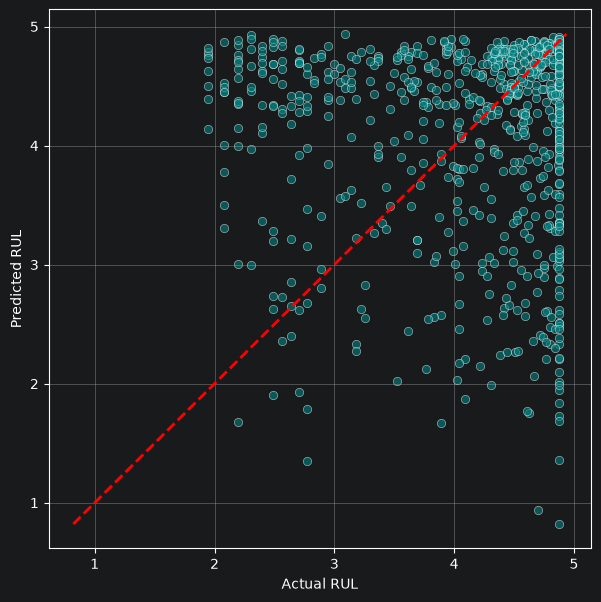

In [11]:
# Plot predictions vs actual
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='teal')
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.grid(True)
plt.show()

In [12]:
y_test.shape, y_pred.shape

((707,), (707,))

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error
metrics = {
                # 'accuracy': accuracy_score(y_test, y_pred),
                'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
            }
print(metrics)
print(np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred))))

{'rmse': np.float64(1.2289168486529165)}
59.928888523712004
